# AI-Generated Image Detection using CNNs

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

tf.random.set_seed(42)
np.random.seed(42)

IMAGE_SIZE = (32, 32)
BATCH_SIZE = 32

## 1. Load the data


In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    'cifake-images/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',   
    shuffle=True,
    seed=42,
)

class_names = train_ds.class_names
print('Class order:', class_names)

Found 100000 files belonging to 2 classes.
Class order: ['FAKE', 'REAL']


2026-09-03 19:29:32.354805: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-09-03 19:29:32.354953: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-03 19:29:32.354960: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-09-03 19:29:32.355192: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-03 19:29:32.355201: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    'cifake-images/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False, 
)
print('Class order:', test_ds.class_names)

Found 20000 files belonging to 2 classes.
Class order: ['FAKE', 'REAL']


### EDA: class balance and a visual sample


In [4]:
labels_list = []
for _, labels in train_ds:
    labels_list.append(labels.numpy())
all_labels = np.concatenate(labels_list).ravel()

fake_count = int((all_labels == 0).sum())
real_count = int((all_labels == 1).sum())
print(f'FAKE: {fake_count}  REAL: {real_count}  (ratio {fake_count / (fake_count + real_count):.2%} / {real_count / (fake_count + real_count):.2%})')

FAKE: 50000  REAL: 50000  (ratio 50.00% / 50.00%)


2026-09-03 19:29:34.810444: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-09-03 19:29:34.919533: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


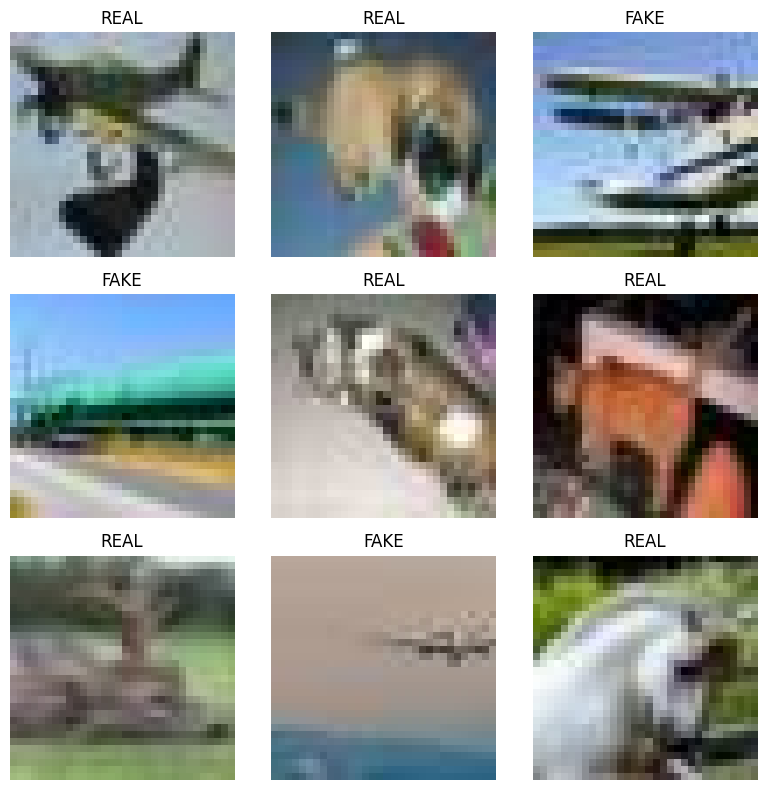

In [5]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(labels[i][0])])
        plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Preprocessing, validation split, and augmentation


In [6]:
normalization_layer = layers.Rescaling(1.0 / 255)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, augment=False, shuffle=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=42)
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

# Split off 10% of the training batches for validation, before augmenting,
# so validation always sees clean, unaltered images.
n_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = max(1, n_batches // 10)

raw_val_ds = train_ds.take(val_batches)
raw_train_ds = train_ds.skip(val_batches)

train_ds_final = prepare(raw_train_ds, augment=True, shuffle=True)
val_ds_final = prepare(raw_val_ds)
test_ds_final = prepare(test_ds)

## 3. Baseline CNN


In [7]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(16, (3, 3), padding='same', strides=2, activation='relu'),
        layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.1),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.1),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.1),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,105 (410.57 KB)

 Trainable params: 105,105 (410.57 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
baseline_history = baseline_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=12,
)

Epoch 1/12


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-09-03 19:29:35.681871: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2813/2813 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - accuracy: 0.7985 - loss: 0.4246 - val_accuracy: 0.8102 - val_loss: 0.4033
Epoch 2/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.8592 - loss: 0.3256 - val_accuracy: 0.8570 - val_loss: 0.3271
Epoch 3/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.8740 - loss: 0.2960 - val_accuracy: 0.8659 - val_loss: 0.3082
Epoch 4/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.8601 - loss: 0.4346 - val_accuracy: 0.5025 - val_loss: 4.7039
Epoch 5/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.7682 - loss: 0.6222 - val_accuracy: 0.8183 - val_loss: 0.4051
Epoch 6/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.8530 - loss: 0.3362 - val_accuracy: 0.8088 - val_loss: 0.4437
Epoch 7/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.8681 - loss: 0.3117 - val_accuracy: 0.8466 - val_loss: 0.3586
Epoch 8/12
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.8760 - loss: 0.29

### Baseline result: diagnosing overfitting

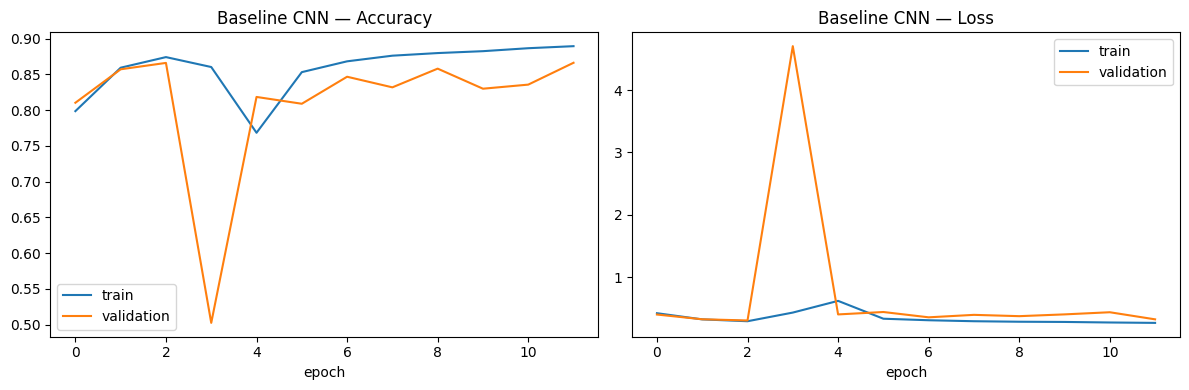

In [9]:
def plot_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'], label='train')
    axes[0].plot(history.history['val_accuracy'], label='validation')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='train')
    axes[1].plot(history.history['val_loss'], label='validation')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_curves(baseline_history, 'Baseline CNN')

## 4. Improved CNN

In [10]:
from tensorflow.keras import regularizers

def build_improved_cnn():
    reg = regularizers.l2(1e-4)

    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(16, (3, 3), padding='same', strides=2, activation='relu', kernel_regularizer=reg),
        layers.Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=reg),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

improved_model = build_improved_cnn()
improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,105 (410.57 KB)

 Trainable params: 105,105 (410.57 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

improved_history = improved_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=20,          # allow more epochs; EarlyStopping decides when to actually stop
    callbacks=[early_stop],
)

Epoch 1/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - accuracy: 0.7671 - loss: 0.4889 - val_accuracy: 0.7740 - val_loss: 0.4793
Epoch 2/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - accuracy: 0.8315 - loss: 0.3933 - val_accuracy: 0.8429 - val_loss: 0.3672
Epoch 3/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - accuracy: 0.8542 - loss: 0.3534 - val_accuracy: 0.8488 - val_loss: 0.3606
Epoch 4/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8666 - loss: 0.3318 - val_accuracy: 0.8233 - val_loss: 0.4301
Epoch 5/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8706 - loss: 0.3225 - val_accuracy: 0.8278 - val_loss: 0.4244
Epoch 6/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8761 - loss: 0.3134 - val_accuracy: 0.8538 - val_loss: 0.3600
Epoch 7/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8775 - loss: 0.3103 - val_accuracy: 0.8768 - val_loss: 0.3131
Epoch 8/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8831 -

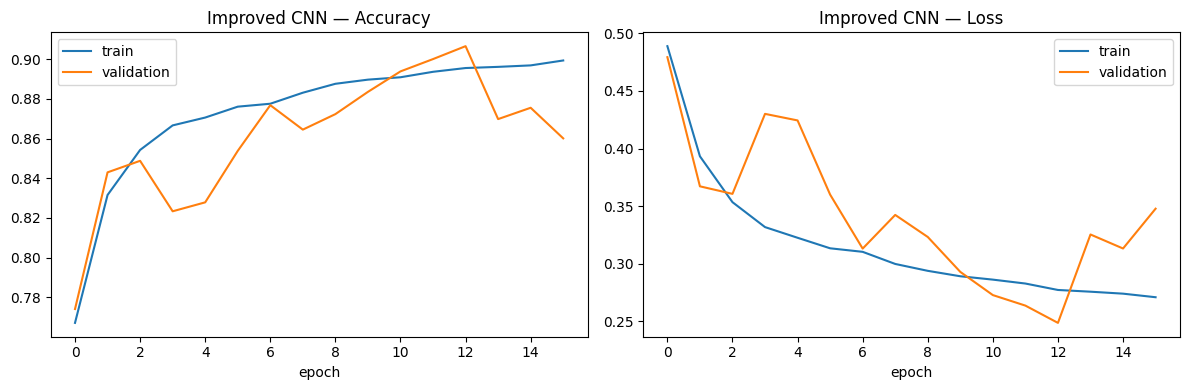

In [12]:
plot_curves(improved_history, 'Improved CNN')

## 4b. Small hyperparameter search: L2 strength and dropout rate


In [13]:
def build_cnn_with_params(l2_weight, dropout_rate):
    reg = regularizers.l2(l2_weight)
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(16, (3, 3), padding='same', strides=2, activation='relu', kernel_regularizer=reg),
        layers.Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate),

        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=reg),
        layers.Dropout(dropout_rate + 0.15),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

l2_options = [1e-5, 1e-4]
dropout_options = [0.15, 0.25]

grid_results = []
for l2_weight in l2_options:
    for dropout_rate in dropout_options:
        candidate = build_cnn_with_params(l2_weight, dropout_rate)
        h = candidate.fit(
            train_ds_final,
            validation_data=val_ds_final,
            epochs=6,   # short runs, just enough to compare relative performance
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
            verbose=0,
        )
        best_val_loss = min(h.history['val_loss'])
        best_val_acc = max(h.history['val_accuracy'])
        grid_results.append((l2_weight, dropout_rate, best_val_loss, best_val_acc))
        print(f'L2={l2_weight:.0e}  dropout={dropout_rate}  best_val_loss={best_val_loss:.4f}  best_val_acc={best_val_acc:.4f}')

L2=1e-05  dropout=0.15  best_val_loss=0.2814  best_val_acc=0.8834
L2=1e-05  dropout=0.25  best_val_loss=0.2525  best_val_acc=0.8993
L2=1e-04  dropout=0.15  best_val_loss=0.3355  best_val_acc=0.8667
L2=1e-04  dropout=0.25  best_val_loss=0.3341  best_val_acc=0.8622


In [14]:
best_config = min(grid_results, key=lambda r: r[2])
print(f'Best config by validation loss: L2={best_config[0]:.0e}, dropout={best_config[1]} '
      f'(val_loss={best_config[2]:.4f}, val_acc={best_config[3]:.4f})')

Best config by validation loss: L2=1e-05, dropout=0.25 (val_loss=0.2525, val_acc=0.8993)


## 5. Ablation: is augmentation the reason accuracy is lower than the baseline?

Epoch 1/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - accuracy: 0.8267 - loss: 0.4022 - val_accuracy: 0.8828 - val_loss: 0.3003
Epoch 2/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.8905 - loss: 0.2881 - val_accuracy: 0.9056 - val_loss: 0.2616
Epoch 3/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 46s 17ms/step - accuracy: 0.9039 - loss: 0.2576 - val_accuracy: 0.9154 - val_loss: 0.2401
Epoch 4/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.9123 - loss: 0.2429 - val_accuracy: 0.9207 - val_loss: 0.2192
Epoch 5/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - accuracy: 0.9169 - loss: 0.2328 - val_accuracy: 0.9195 - val_loss: 0.2200
Epoch 6/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - accuracy: 0.9184 - loss: 0.2290 - val_accuracy: 0.9257 - val_loss: 0.2090
Epoch 7/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - accuracy: 0.9215 - loss: 0.2212 - val_accuracy: 0.9294 - val_loss: 0.1952
Epoch 8/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - accuracy: 0.9236 -

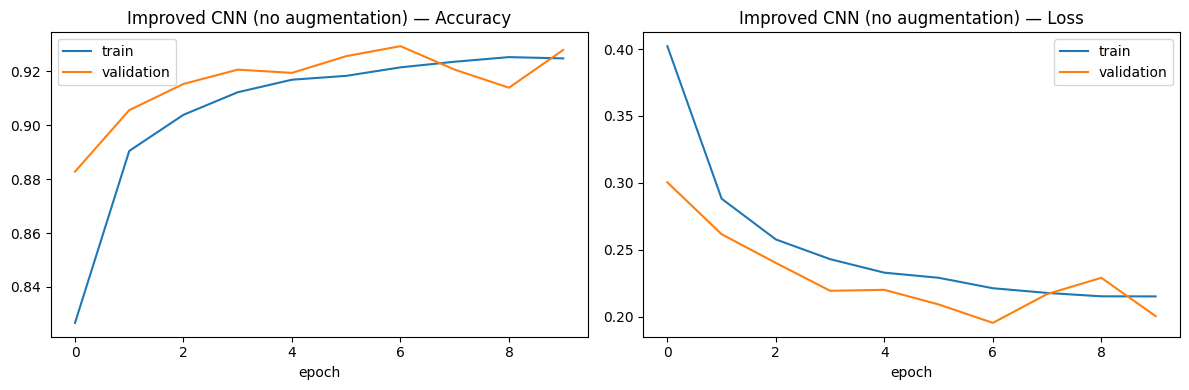

In [15]:
train_ds_no_aug = prepare(raw_train_ds, augment=False, shuffle=True)

no_aug_model = build_improved_cnn()
no_aug_history = no_aug_model.fit(
    train_ds_no_aug,
    validation_data=val_ds_final,
    epochs=20,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
)

plot_curves(no_aug_history, 'Improved CNN (no augmentation)')

## 5b. Transfer learning: ResNet50

In [16]:
RESNET_SIZE = (96, 96)

def prepare_for_resnet(ds, augment=False, shuffle=False):
    ds = ds.map(lambda x, y: (tf.image.resize(x, RESNET_SIZE), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=42)
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

# Rebuild the raw (pre-normalization) splits at the larger resolution.
raw_val_ds_resnet = raw_val_ds
raw_train_ds_resnet = raw_train_ds

train_ds_resnet = prepare_for_resnet(raw_train_ds_resnet, augment=True, shuffle=True)
val_ds_resnet = prepare_for_resnet(raw_val_ds_resnet)
test_ds_resnet = prepare_for_resnet(test_ds)

In [17]:
resnet_base = tf.keras.applications.ResNet50(
    input_shape=(96, 96, 3),
    include_top=False,   # drop ResNet50's original 1000-class ImageNet head
    weights='imagenet',
)
resnet_base.trainable = False   # freeze: only the new head below gets trained

resnet_model = models.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Rescaling(2.0, offset=-1.0),  # ResNet50 (Keras applications) expects [-1, 1], not [0, 1]
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
resnet_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 204s 70ms/step - accuracy: 0.6753 - loss: 0.6105 - val_accuracy: 0.7339 - val_loss: 0.5637
Epoch 2/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 267s 95ms/step - accuracy: 0.7103 - loss: 0.5709 - val_accuracy: 0.7458 - val_loss: 0.5421
Epoch 3/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 175s 62ms/step - accuracy: 0.7161 - loss: 0.5613 - val_accuracy: 0.7496 - val_loss: 0.5337
Epoch 4/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 201s 72ms/step - accuracy: 0.7216 - loss: 0.5538 - val_accuracy: 0.7516 - val_loss: 0.5295
Epoch 5/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 210s 75ms/step - accuracy: 0.7216 - loss: 0.5524 - val_accuracy: 0.7542 - val_loss: 0.5224
Epoch 6/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 210s 75ms/step - accuracy: 0.7239 - loss: 0.5484 - val_accuracy: 0.7551 - val_loss: 0.5196
Epoch 7/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 202s 72ms/step - accuracy: 0.7230 - loss: 0.5496 - val_accuracy: 0.7552 - val_loss: 0.5182
Epoch 8/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 200s 71ms/step - accuracy: 

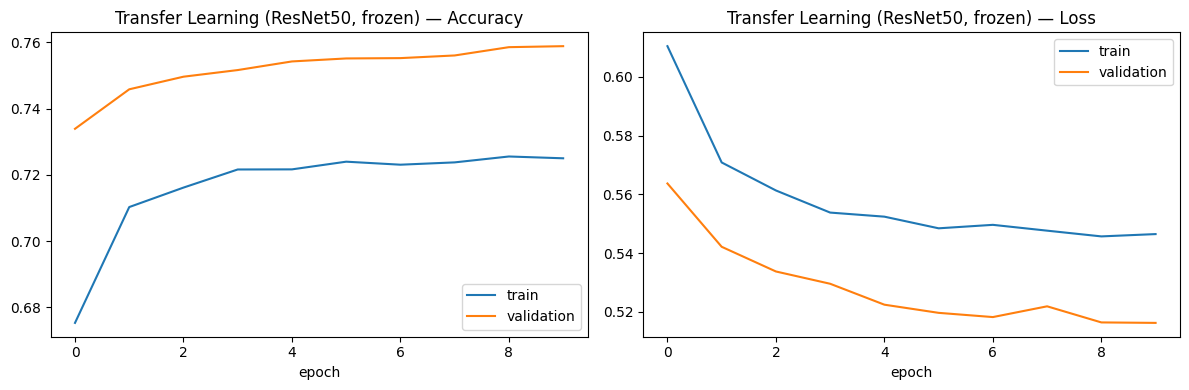

In [18]:
resnet_history = resnet_model.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
)

plot_curves(resnet_history, 'Transfer Learning (ResNet50, frozen)')

## 6. Evaluation on the test set


2026-09-03 20:49:32.404599: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
=== Baseline CNN (overfit) ===
              precision    recall  f1-score   support

        FAKE       0.80      0.97      0.88     10000
        REAL       0.97      0.76      0.85     10000

    accuracy                           0.87     20000
   macro avg       0.88      0.87      0.86     20000
weighted avg       0.88      0.87      0.86     20000



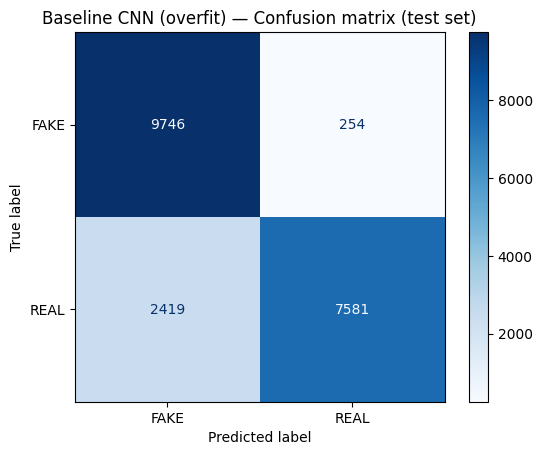

  8/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step    

2026-09-03 20:49:34.349518: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
=== Improved CNN (regularized + augmented) ===
              precision    recall  f1-score   support

        FAKE       0.87      0.96      0.91     10000
        REAL       0.96      0.86      0.90     10000

    accuracy                           0.91     20000
   macro avg       0.91      0.91      0.91     20000
weighted avg       0.91      0.91      0.91     20000



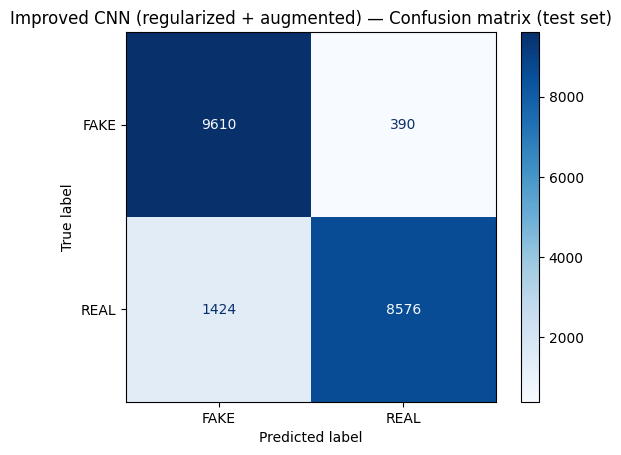

 28/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step    

2026-09-03 20:49:35.475953: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
=== Improved CNN (regularized, no augmentation) ===
              precision    recall  f1-score   support

        FAKE       0.94      0.92      0.93     10000
        REAL       0.93      0.94      0.93     10000

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000



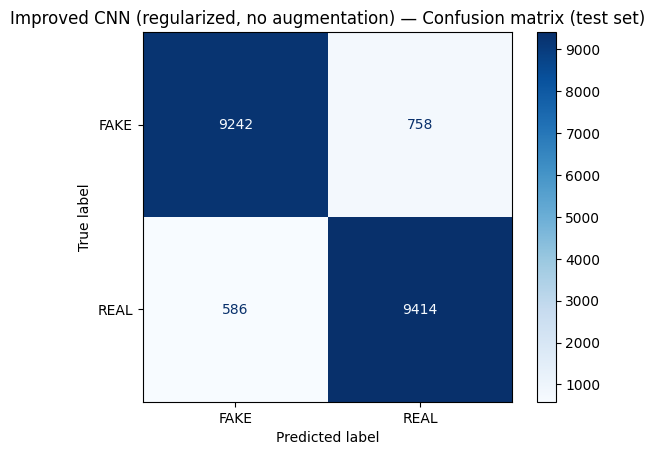

2026-09-03 20:49:37.453178: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step
=== Transfer Learning (ResNet50, frozen) ===
              precision    recall  f1-score   support

        FAKE       0.75      0.80      0.77     10000
        REAL       0.78      0.73      0.76     10000

    accuracy                           0.76     20000
   macro avg       0.77      0.76      0.76     20000
weighted avg       0.77      0.76      0.76     20000



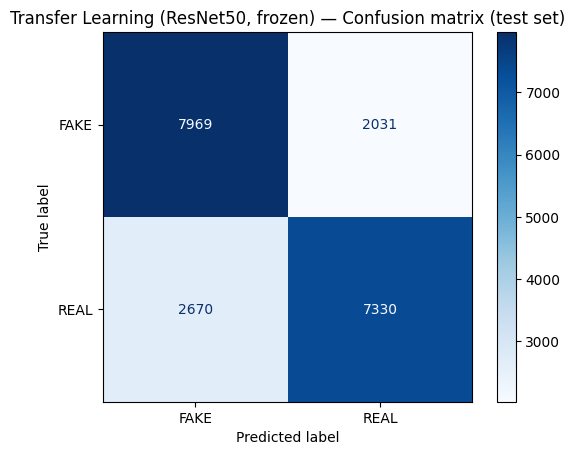

In [19]:
def evaluate_model(model, name, ds=None):
    eval_ds = ds if ds is not None else test_ds_final
    y_true = np.concatenate([y.numpy() for _, y in eval_ds], axis=0).astype(int).ravel()
    y_prob = model.predict(eval_ds).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f'=== {name} ===')
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f'{name} — Confusion matrix (test set)')
    plt.show()

    return y_true, y_prob, y_pred

baseline_results = evaluate_model(baseline_model, 'Baseline CNN (overfit)')
improved_results = evaluate_model(improved_model, 'Improved CNN (regularized + augmented)')
no_aug_results = evaluate_model(no_aug_model, 'Improved CNN (regularized, no augmentation)')
resnet_results = evaluate_model(resnet_model, 'Transfer Learning (ResNet50, frozen)', ds=test_ds_resnet)

### ROC curve and AUC

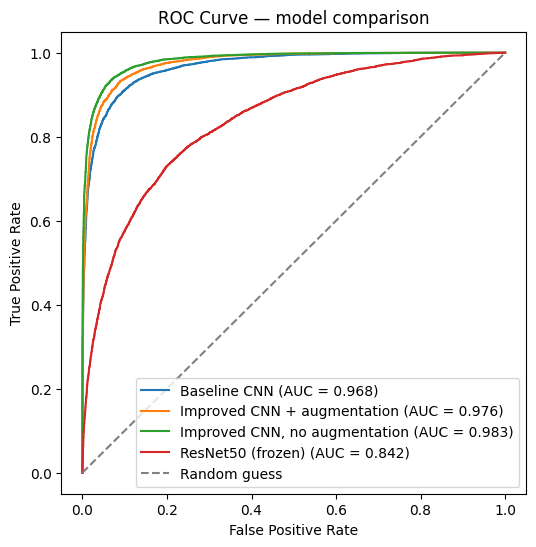

In [20]:
plt.figure(figsize=(6, 6))
for (y_true, y_prob, _), name in [
    (baseline_results, 'Baseline CNN'),
    (improved_results, 'Improved CNN + augmentation'),
    (no_aug_results, 'Improved CNN, no augmentation'),
    (resnet_results, 'ResNet50 (frozen)'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — model comparison')
plt.legend()
plt.show()

### Side-by-side summary


In [21]:
for (y_true, y_prob, y_pred), name in [
    (baseline_results, 'Baseline CNN (overfit)'),
    (improved_results, 'Improved CNN (regularized + augmented)'),
    (no_aug_results, 'Improved CNN (regularized, no augmentation)'),
    (resnet_results, 'Transfer Learning (ResNet50, frozen)'),
]:
    acc = (y_true == y_pred).mean()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f'{name:42s}  accuracy={acc:.4f}  AUC={roc_auc:.4f}')

Baseline CNN (overfit)                      accuracy=0.8663  AUC=0.9678
Improved CNN (regularized + augmented)      accuracy=0.9093  AUC=0.9761
Improved CNN (regularized, no augmentation)  accuracy=0.9328  AUC=0.9826
Transfer Learning (ResNet50, frozen)        accuracy=0.7650  AUC=0.8418


## 6b. Threshold tuning: trading precision for recall


In [22]:
y_true_thresh, y_prob_thresh, _ = no_aug_results

thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7]
for t in thresholds_to_try:
    y_pred_t = (y_prob_thresh >= t).astype(int)
    report = classification_report(y_true_thresh, y_pred_t, target_names=class_names, output_dict=True)
    fake_precision = report[class_names[0]]['precision']
    fake_recall = report[class_names[0]]['recall']
    print(f'threshold={t}  FAKE precision={fake_precision:.3f}  FAKE recall={fake_recall:.3f}')

threshold=0.3  FAKE precision=0.966  FAKE recall=0.866
threshold=0.4  FAKE precision=0.952  FAKE recall=0.901
threshold=0.5  FAKE precision=0.940  FAKE recall=0.924
threshold=0.6  FAKE precision=0.924  FAKE recall=0.943
threshold=0.7  FAKE precision=0.904  FAKE recall=0.958


## 7. Error analysis

In [23]:
def collect_misclassified(model, ds, class_names, max_examples=9):
    real_as_fake = []
    fake_as_real = []
    for images, labels in ds:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        labels_np = labels.numpy().astype(int).ravel()
        for img, true_label, pred_label, prob in zip(images.numpy(), labels_np, preds, probs):
            if true_label == 1 and pred_label == 0 and len(real_as_fake) < max_examples:
                real_as_fake.append((img, prob))
            elif true_label == 0 and pred_label == 1 and len(fake_as_real) < max_examples:
                fake_as_real.append((img, prob))
        if len(real_as_fake) >= max_examples and len(fake_as_real) >= max_examples:
            break
    return real_as_fake, fake_as_real

real_as_fake, fake_as_real = collect_misclassified(no_aug_model, test_ds_final, class_names)

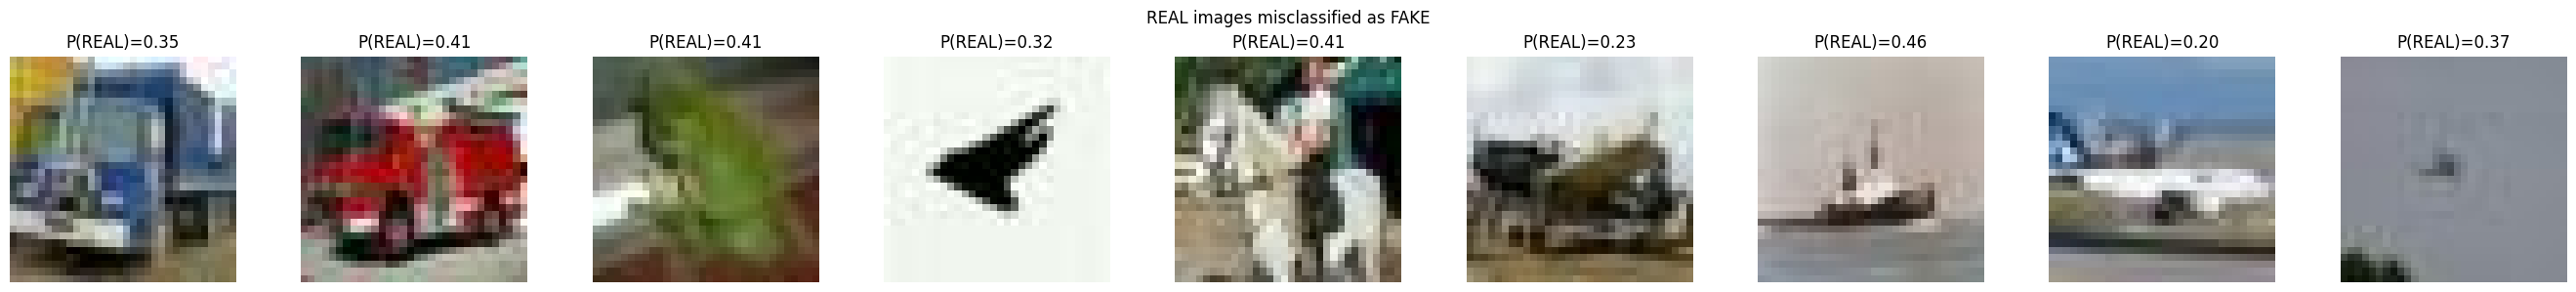

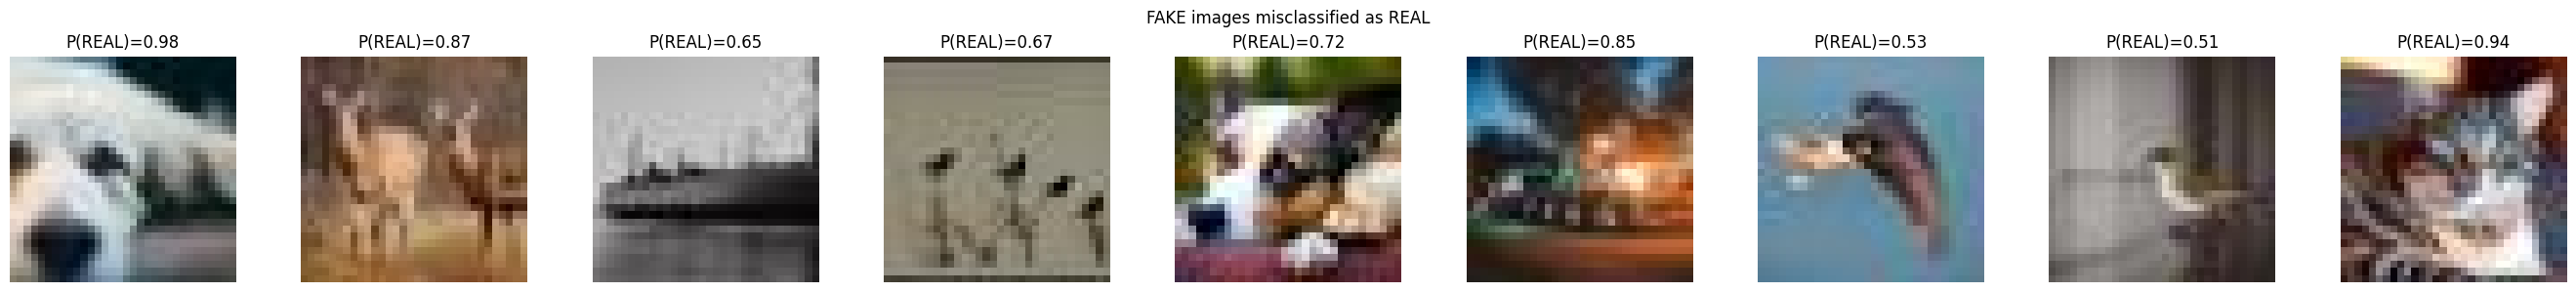

In [24]:
def plot_misclassified(examples, title):
    n = len(examples)
    if n == 0:
        print(f'No examples found for: {title}')
        return
    plt.figure(figsize=(3 * n, 3))
    for i, (img, prob) in enumerate(examples):
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f'P(REAL)={prob:.2f}')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_misclassified(real_as_fake, 'REAL images misclassified as FAKE')
plot_misclassified(fake_as_real, 'FAKE images misclassified as REAL')

## 8. Grad-CAM: visualizing what the model is looking at

In [25]:
last_conv_layer_name = [layer.name for layer in no_aug_model.layers if isinstance(layer, layers.Conv2D)][-1]
print('Using layer:', last_conv_layer_name)

inputs = tf.keras.Input(shape=(32, 32, 3))
x = inputs
conv_output = None
for layer in no_aug_model.layers:
    x = layer(x)
    if layer.name == last_conv_layer_name:
        conv_output = x

grad_model = models.Model(inputs=inputs, outputs=[conv_output, x])

def make_gradcam_heatmap(img_array, grad_model):
    img_array = np.expand_dims(img_array, axis=0)
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[0][0]   # single sigmoid output, so this is P(REAL)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))   # importance weight per feature map

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)   # normalize to [0, 1]
    return heatmap.numpy()

Using layer: conv2d_41


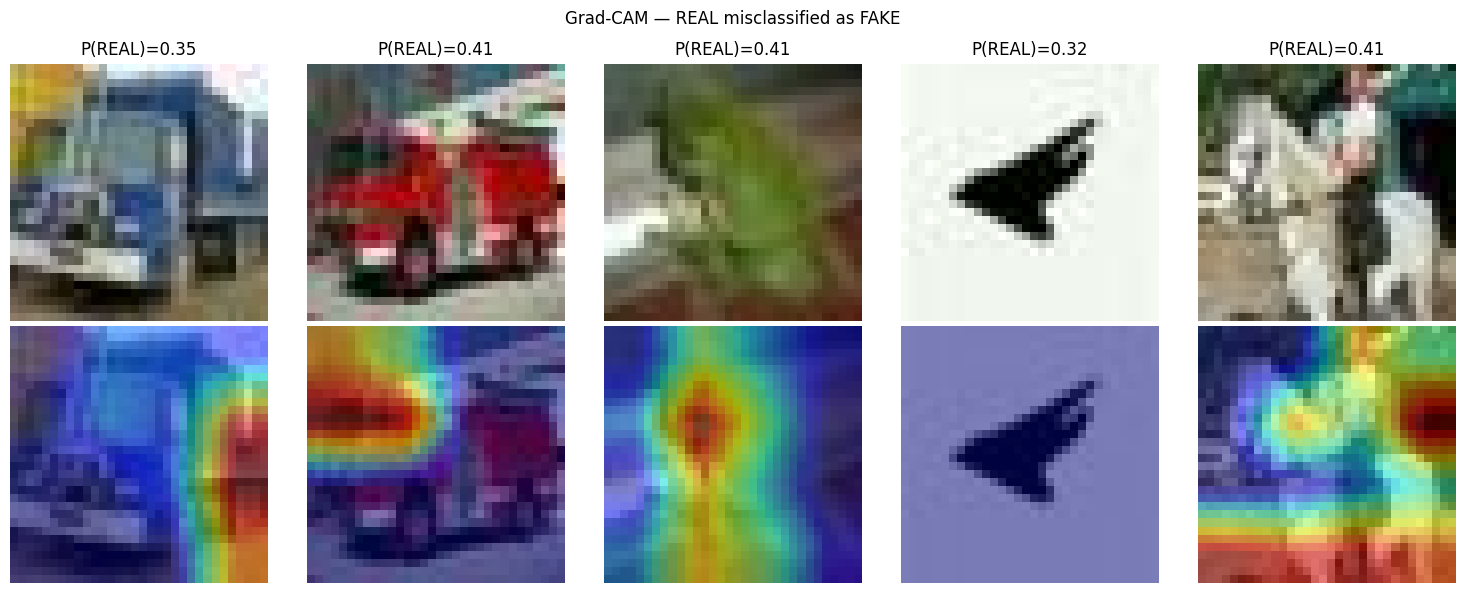

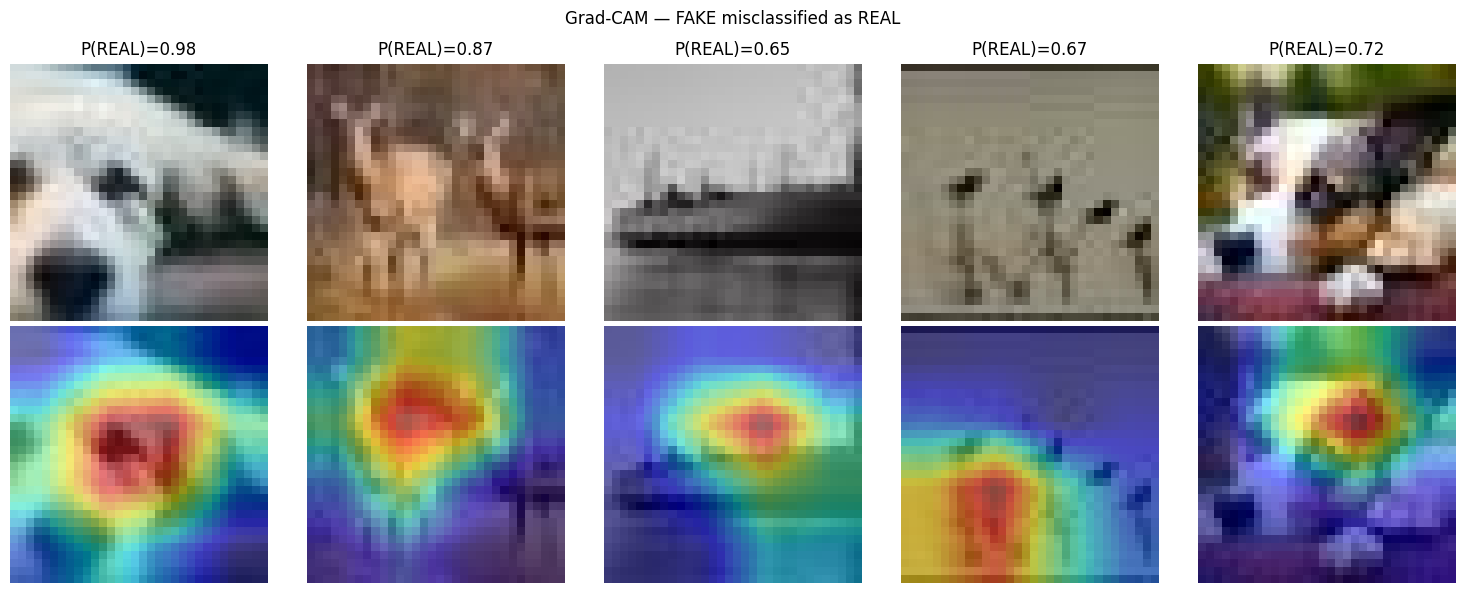

In [26]:
def plot_gradcam(examples, title, grad_model):
    n = len(examples)
    if n == 0:
        print(f'No examples available for: {title}')
        return
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for i, (img, prob) in enumerate(examples):
        heatmap = make_gradcam_heatmap(img, grad_model)
        heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (32, 32)).numpy().squeeze()

        axes[0, i].imshow(img)
        axes[0, i].set_title(f'P(REAL)={prob:.2f}')
        axes[0, i].axis('off')

        axes[1, i].imshow(img)
        axes[1, i].imshow(heatmap_resized, cmap='jet', alpha=0.5)
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Original')
    axes[1, 0].set_ylabel('Grad-CAM')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_gradcam(real_as_fake[:5], 'Grad-CAM — REAL misclassified as FAKE', grad_model)
plot_gradcam(fake_as_real[:5], 'Grad-CAM — FAKE misclassified as REAL', grad_model)

## 9. Out-of-distribution test: images the model has never seen

In [27]:
from PIL import Image

ood_real_paths = ["outside_test/child.jpeg"]
ood_fake_paths = ["outside_test/drag.jpeg"]

def load_and_preprocess(path):
    img = Image.open(path).convert('RGB').resize((32, 32))
    return np.array(img) / 255.0

def run_ood_test(model, real_paths, fake_paths, class_names):
    results = []
    for path in real_paths:
        arr = load_and_preprocess(path)
        prob = model.predict(np.expand_dims(arr, axis=0), verbose=0)[0][0]
        pred = class_names[1] if prob >= 0.5 else class_names[0]
        results.append((path, 'REAL', pred, prob))
    for path in fake_paths:
        arr = load_and_preprocess(path)
        prob = model.predict(np.expand_dims(arr, axis=0), verbose=0)[0][0]
        pred = class_names[1] if prob >= 0.5 else class_names[0]
        results.append((path, 'FAKE', pred, prob))
    return results

if ood_real_paths or ood_fake_paths:
    ood_results = run_ood_test(no_aug_model, ood_real_paths, ood_fake_paths, class_names)
    correct = 0
    for path, true_label, pred_label, prob in ood_results:
        is_correct = (true_label in pred_label.upper())
        correct += int(is_correct)
        print(f'{path:40s}  true={true_label:5s}  predicted={pred_label:20s}  P(REAL)={prob:.3f}  {"OK" if is_correct else "WRONG"}')
    print(f'\nOut-of-distribution accuracy: {correct}/{len(ood_results)} = {correct / len(ood_results):.2%}')
else:
    print('No out-of-distribution images added yet - fill in ood_real_paths and ood_fake_paths above and re-run this cell.')

outside_test/child.jpeg                   true=REAL   predicted=REAL                  P(REAL)=0.660  OK
outside_test/drag.jpeg                    true=FAKE   predicted=FAKE                  P(REAL)=0.163  OK

Out-of-distribution accuracy: 2/2 = 100.00%


## 10. Save the best model


In [28]:
no_aug_model.save('Model.h5')